# 목차
- 분석 목적
- 전처리
- 고객 단위 RFM + 확장 피처 생성
- RFM 테이블
- RMF 점수화 
- 세그먼트 정의
- 세그먼트별 매출 기여도 + 시각화
- 코호트 분석
- 재구매 예측 모델

# 분석 목적
- 고객 구매 데이터를 기반으로 RFM 분석을 수행한다.
- 고객을 세그먼트화하여 매출 기여도를 파악한다.
- 고가치 고객군과 이탈 위험 고객군을 식별한다.

In [1]:
import pandas as pd
import datetime as dt

# 데이터 로드
df = pd.read_excel("Online Retail.xlsx")

print("데이터 크기:", df.shape)
df.head()

데이터 크기: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


# 전처리
- Quantity > 0 : 반품 제거
- UnitPrice > 0 : 무료 샘플 제거
- 상위 1% 제거 : 극단적 이상치로 인한 왜곡 방지
- UK 데이터만 사용 : 동일 시장 기준 분석

In [2]:
# 1. CustomerID 없는 행 제거
df = df.dropna(subset=["CustomerID"])

In [3]:
# 2. 중복 제거
df = df.drop_duplicates()

In [4]:
# 3. 수량이 0 이하이거나 단가가 0 이하인 행 제거
df = df[df["Quantity"] > 0]
df = df[df["UnitPrice"] > 0]

In [5]:
# 4. 환불 주문 제거 (InvoiceNo가 C로 시작하는 경우)
df["InvoiceNo"] = df["InvoiceNo"].astype(str)
df = df[~df["InvoiceNo"].str.startswith("C")]


In [6]:
# 5. 영국 데이터만 사용
df = df[df["Country"] == "United Kingdom"]

In [7]:
# 6. 날짜 타입 변환
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [8]:
# 7. 연도, 월 변수 생성
df["Year"] = df["InvoiceDate"].dt.year
df["Month"] = df["InvoiceDate"].dt.month

In [9]:
# 8. 총 매출 계산
df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

In [10]:
# 9. StockCode 문자형 변환
df["StockCode"] = df["StockCode"].astype(str)

In [11]:
# 10. POST 제거
df = df[~df["StockCode"].str.contains("POST", na=False)]

In [12]:
# 11. 알파벳 포함 코드 제거
df = df[~df["StockCode"].str.contains("[A-Za-z]", regex=True)]

In [13]:
# 12. 이상치 제거 (상위 1%)
price_limit = df["UnitPrice"].quantile(0.99)
quantity_limit = df["Quantity"].quantile(0.99)

In [14]:
df = df[df["UnitPrice"] < price_limit]
df = df[df["Quantity"] < quantity_limit]

In [15]:
print("전처리 끝!")
print("데이터 크기:", df.shape)

전처리 끝!
데이터 크기: (308975, 11)


# 고객 단위 RFM + 확장 피처 생성

In [16]:
from datetime import timedelta
reference_date = df["InvoiceDate"].max() + timedelta(days=1)

In [17]:
rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (reference_date - x.max()).days,
    "InvoiceNo": "nunique",
    "TotalAmount": "sum"
}).reset_index()

In [18]:
rfm.columns = ["CustomerID", "Recency", "Frequency", "Monetary"]

In [19]:
# 평균 구매 간격
interval_df = df.sort_values(["CustomerID", "InvoiceDate"])
interval_df["PrevDate"] = interval_df.groupby("CustomerID")["InvoiceDate"].shift(1)
interval_df["Interval"] = (interval_df["InvoiceDate"] - interval_df["PrevDate"]).dt.days

In [20]:
avg_interval = interval_df.groupby("CustomerID")["Interval"].mean().reset_index()

In [21]:
rfm = rfm.merge(avg_interval, on="CustomerID", how="left")

In [22]:
# 평균 SKU 수
avg_sku = df.groupby(["CustomerID", "InvoiceNo"])["StockCode"].nunique().groupby("CustomerID").mean().reset_index()
avg_sku.columns = ["CustomerID", "AvgSKU"]

In [23]:
rfm = rfm.merge(avg_sku, on="CustomerID", how="left")

In [24]:
print("RFM 고객 수:", rfm.shape)
print(rfm.head())

RFM 고객 수: (3844, 6)
   CustomerID  Recency  Frequency  Monetary  Interval     AvgSKU
0     12747.0        2         11   3513.01  4.594937   7.272727
1     12748.0        1        196  25148.63  0.077655  19.275510
2     12749.0        4          5   3651.78  1.125000  37.000000
3     12820.0        3          4    924.64  5.649123  14.500000
4     12821.0      214          1     92.72  0.000000   6.000000


# RFM 테이블
고객을 구매 패턴 기준으로 나누는 분석, 최근에 샀는지, 얼마나 자주 샀는지, 얼마나 많이 썼는지를 기준으로 고객을 분류하는 것 ->RMF / Recency, Frequency, Monetary

In [25]:
import datetime as dt

# Invoice 단위 집계
invoice_df = df.groupby(
    ["CustomerID", "InvoiceNo"]
).agg(
    OrderDate=("InvoiceDate", "min"),
    OrderAmount=("TotalAmount", "sum")
).reset_index()

In [26]:
# 기준 날짜 설정
reference_date = invoice_df["OrderDate"].max() + dt.timedelta(days=1)

In [27]:
# RFM 생성
rfm = invoice_df.groupby("CustomerID").agg(
    Recency=("OrderDate", lambda x: (reference_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("OrderAmount", "sum")
).reset_index()

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12747.0,2,11,3513.01
1,12748.0,1,196,25148.63
2,12749.0,4,5,3651.78
3,12820.0,3,4,924.64
4,12821.0,214,1,92.72


# RMF 점수화

In [28]:
rfm["R_score"] = pd.qcut(rfm["Recency"], 5, labels=[5,4,3,2,1])
rfm["F_score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 5, labels=[1,2,3,4,5])
rfm["M_score"] = pd.qcut(rfm["Monetary"], 5, labels=[1,2,3,4,5])

rfm["RFM_score"] = (
    rfm["R_score"].astype(int) +
    rfm["F_score"].astype(int) +
    rfm["M_score"].astype(int)
)
rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score
0,12747.0,2,11,3513.01,5,5,5,15
1,12748.0,1,196,25148.63,5,5,5,15
2,12749.0,4,5,3651.78,5,4,5,14
3,12820.0,3,4,924.64,5,4,4,13
4,12821.0,214,1,92.72,1,1,1,3


# 세그먼트 정의

In [29]:
def segment_customer(row):
    if row["R_score"] == 5 and row["F_score"] >= 4:
        return "VIP"
    elif row["F_score"] >= 4:
        return "Loyal"
    elif row["R_score"] <= 2:
        return "At_Risk"
    elif row["Frequency"] == 1:
        return "New"
    else:
        return "Normal"

rfm["Segment"] = rfm.apply(segment_customer, axis=1)

print(rfm["Segment"].value_counts())

Segment
At_Risk    1276
Loyal       972
VIP         566
Normal      557
New         473
Name: count, dtype: int64


# 세그먼트별 매출 기여도 + 시각화

Segment
VIP        2211359.93
Loyal      1672431.48
At_Risk     449033.32
Normal      363034.07
New         129981.92
Name: Monetary, dtype: float64


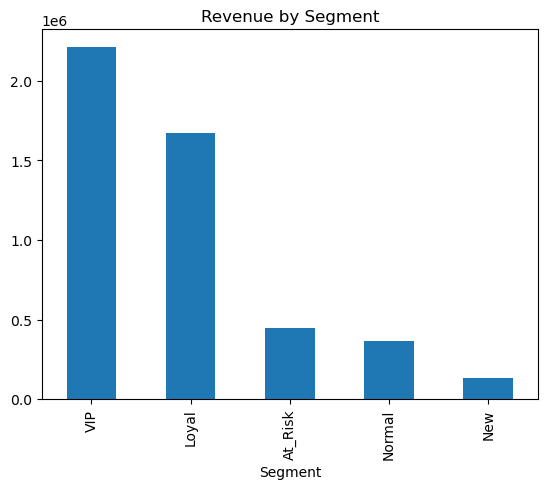

In [30]:
import matplotlib.pyplot as plt
segment_revenue = rfm.groupby("Segment")["Monetary"].sum().sort_values(ascending=False)

print(segment_revenue)

segment_revenue.plot(kind="bar")
plt.title("Revenue by Segment")
plt.show()

# 코호트 분석

In [31]:
df["FirstPurchase"] = df.groupby("CustomerID")["InvoiceDate"].transform("min")
df["CohortMonth"] = df["FirstPurchase"].dt.to_period("M")
df["OrderMonth"] = df["InvoiceDate"].dt.to_period("M")

In [32]:
df["CohortIndex"] = (df["OrderMonth"] - df["CohortMonth"]).apply(lambda x: x.n)

In [33]:
cohort = df.groupby(["CohortMonth", "CohortIndex"])["CustomerID"].nunique().reset_index()


In [34]:
ohort_pivot = cohort.pivot(index="CohortMonth", columns="CohortIndex", values="CustomerID")

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

In [36]:
cohort_pivot = cohort.pivot(
    index="CohortMonth",
    columns="CohortIndex",
    values="CustomerID"
)

In [37]:
cohort_size = cohort_pivot.iloc[:, 0]
retention = cohort_pivot.divide(cohort_size, axis=0)

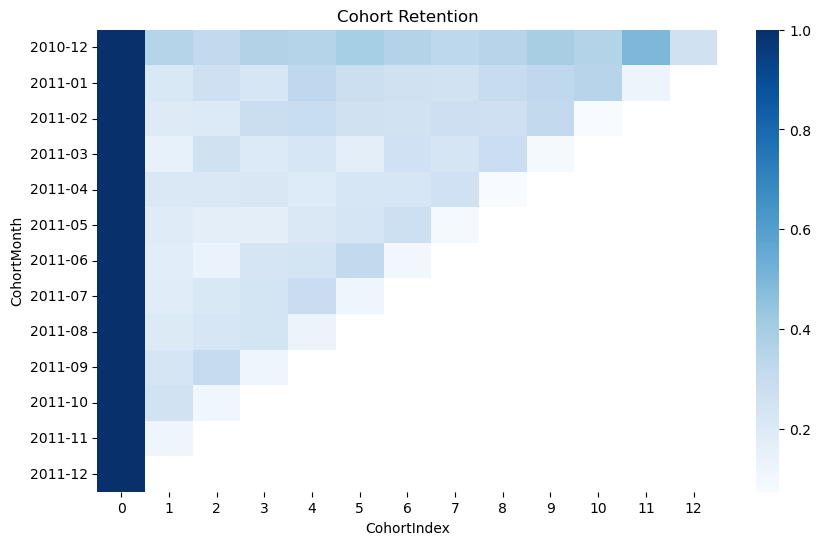

In [38]:
plt.figure(figsize=(10,6))
sns.heatmap(retention, annot=False, cmap="Blues")
plt.title("Cohort Retention")
plt.show()

# 재구매 예측 모델

In [39]:
df["NextPurchase"] = df.groupby("CustomerID")["InvoiceDate"].shift(-1)

In [40]:
# 라벨 생성 (30일 이내 재구매 여부)
df["NextPurchase"] = df.groupby("CustomerID")["InvoiceDate"].shift(-1)

In [41]:
df["DaysToNext"] = (df["NextPurchase"] - df["InvoiceDate"]).dt.days

In [43]:
df["Repurchase_30"] = df["DaysToNext"] <= 30